In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


# Dataset overview

In [3]:
df.shape

(10000, 14)

In [4]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [5]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,39
Age,75
Tenure,0
Balance,0
NumOfProducts,0


In [6]:
df.duplicated().sum()

np.int64(0)

#Data cleaning

In [7]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Age'].fillna(df['Age'].median(),inplace=True)

In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


#Demographic Analysis

Q What is the distribution of customers gender?

In [9]:
df['Gender'].value_counts()

,count
Gender,
Male,5475
Female,4525


Q Does churn rate differ by gender?

In [10]:
churn_rate=df[df['Exited']==1].groupby('Gender')['Exited'].count()*100/df.groupby('Gender')['Exited'].count()
churn_rate

,Exited
Gender,
Female,24.994475
Male,16.547945


<Axes: xlabel='Gender'>

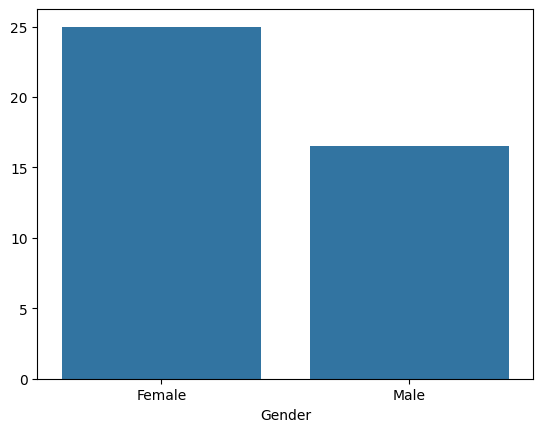

In [11]:
sns.barplot(x=churn_rate.index,y=churn_rate.values)

Q How is churn distributed across different geographies?

In [12]:
cg=df[df['Exited']==1].groupby('Geography')['Exited'].count()
cg

,Exited
Geography,
France,810
Germany,814
Spain,413


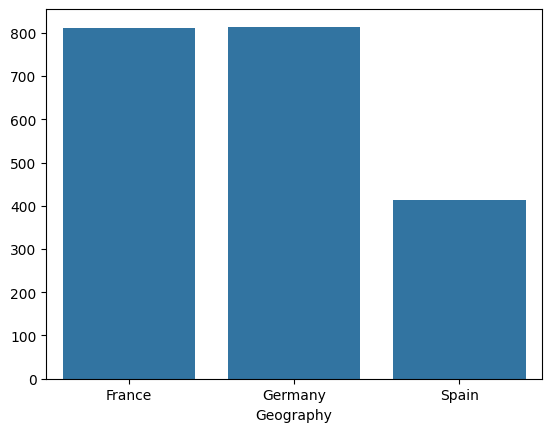

In [13]:
sns.barplot(x=cg.index,y=cg.values)
plt.show()

Q What is the age distribution of the coustomer?

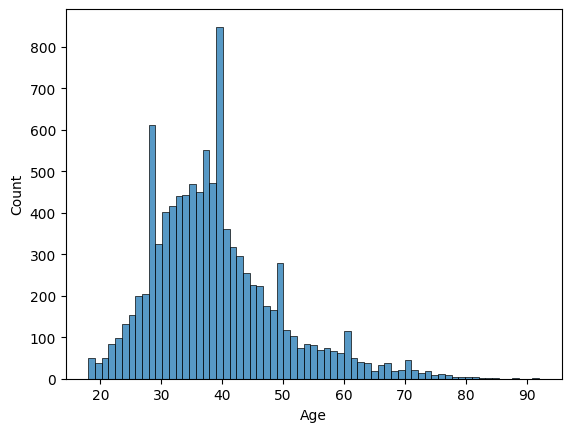

<Figure size 1500x800 with 0 Axes>

In [14]:
sns.histplot(df['Age'])
plt.figure(figsize=(15,8))
plt.show()

Q Which age group has highest churn rate?

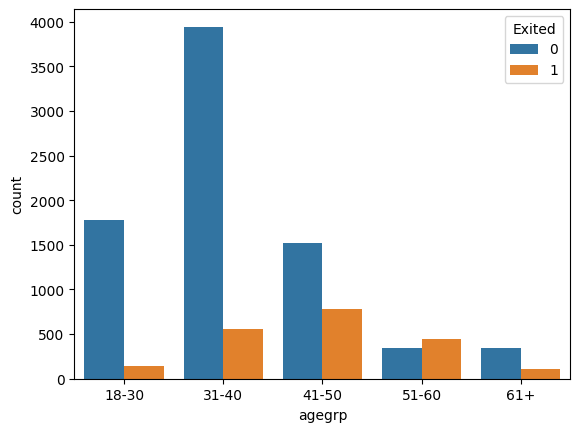

In [15]:
df['agegrp']=pd.cut(df['Age'],bins=[18,30,40,50,60,90],labels=['18-30','31-40','41-50','51-60','61+'])
sns.countplot(x='agegrp',hue='Exited',data=df)
plt.show()

* people of agegroup 41-50 has highest churn rate

# Financial Attributes


Average credit score for churned vs retained customers

In [16]:
avg_crd_score=df.groupby('Exited')['CreditScore'].mean()
avg_crd_score

,CreditScore
Exited,
0,651.853196
1,645.351497


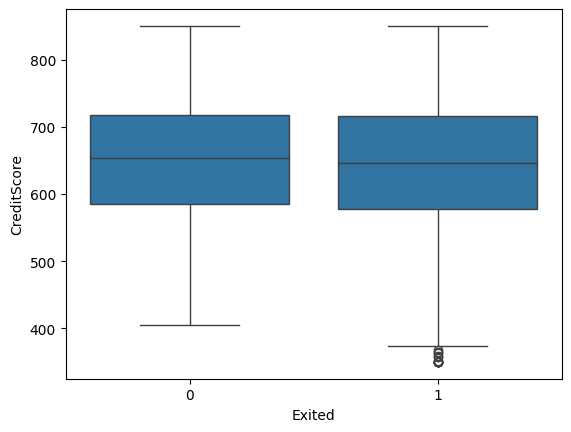

In [17]:
sns.boxplot(x='Exited',y='CreditScore',data=df)
plt.show()

Q How does account balance relate to churn?

In [18]:
df.groupby('Exited')['Balance'].mean()

,Balance
Exited,
0,72745.296779
1,91108.539337


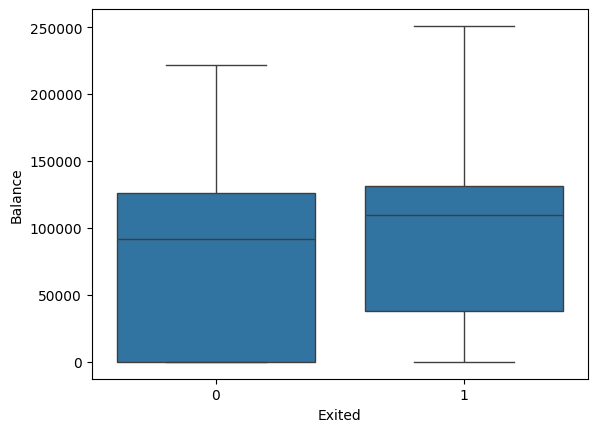

In [19]:
sns.boxplot(x='Exited',y='Balance',data=df)
plt.show()

Q Is there any visible pattern between estimated salary and churn?

In [20]:
df.groupby('Exited')['EstimatedSalary'].mean()

,EstimatedSalary
Exited,
0,99738.391772
1,101465.677531


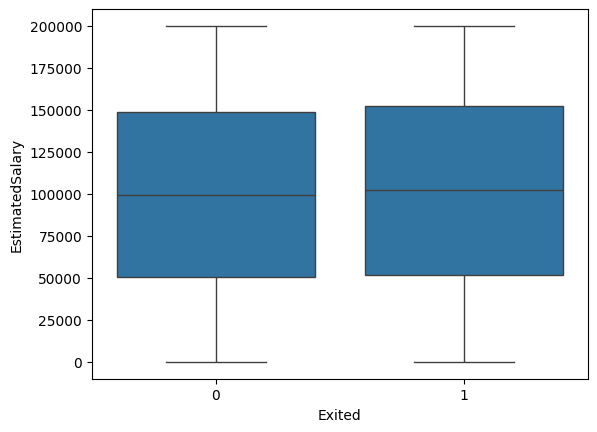

In [21]:
sns.boxplot(x='Exited',y='EstimatedSalary',data=df)
plt.show()

# Customer Behaviour

Q How does tenure affect churn?

In [22]:
t=df.groupby('Exited')['Tenure'].mean()
t

,Tenure
Exited,
0,5.033279
1,4.932744


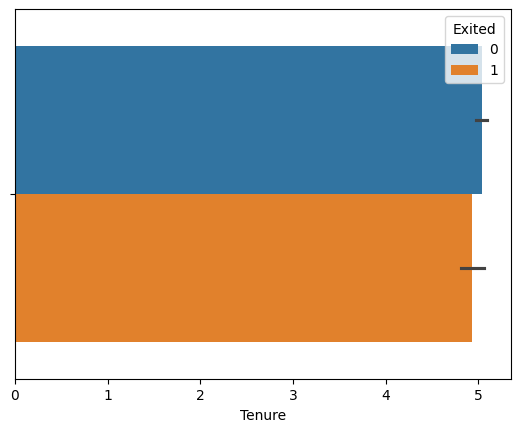

In [23]:
sns.barplot(x='Tenure',hue='Exited',data=df)
plt.show()

Q What is the churn rate based on the number of products customer has?

In [24]:
rate=df.groupby('Exited')['NumOfProducts'].mean()*100
rate

,NumOfProducts
Exited,
0,154.426724
1,147.520864


<Axes: xlabel='NumOfProducts', ylabel='count'>

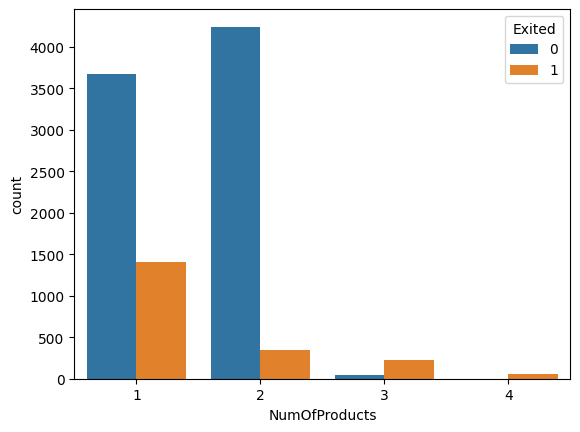

In [25]:
sns.countplot(x='NumOfProducts',hue='Exited',data=df)

Q Do customer with credit card churn more or less?

In [26]:
c=df.groupby('HasCrCard')['Exited'].mean()*100
c

,Exited
HasCrCard,
0,20.814941
1,20.184266


* doesnt seem to have much diference

Q Are inactive members more likely to churn?

In [27]:
d=df.groupby('IsActiveMember')['Exited'].mean()*100
d

,Exited
IsActiveMember,
0,26.850897
1,14.269074


* yes inactive members are more likely to get churned

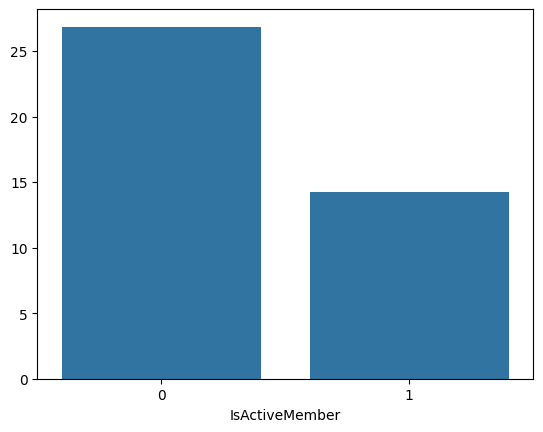

In [28]:
sns.barplot(x=d.index,y=d.values)
plt.show()

# Multivariate Insights

Q Do older women churn more tha older men?

In [29]:
older=df[df['Age']>50]
rate=older.groupby('Gender')['Exited'].mean()*100
rate

,Exited
Gender,
Female,52.852349
Male,37.025797


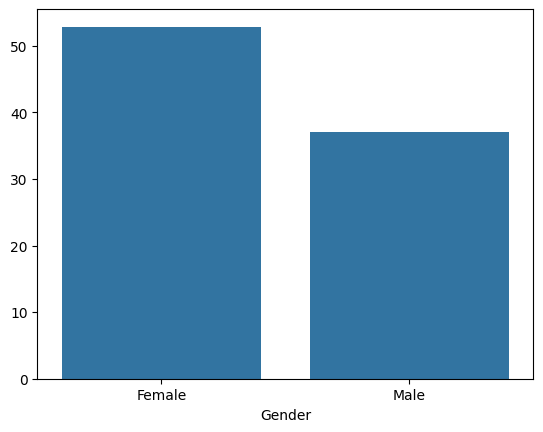

In [30]:
sns.barplot(x=rate.index,y=rate.values)
plt.show()

* older females are more likely to churn than older man

Q Among high credit score customers,does churn differ across geographies?

In [31]:
high_credit=df[df['CreditScore']>700]
rate=high_credit.groupby('Geography')['Exited'].mean()*100
rate


,Exited
Geography,
France,14.700193
Germany,32.752179
Spain,16.797900


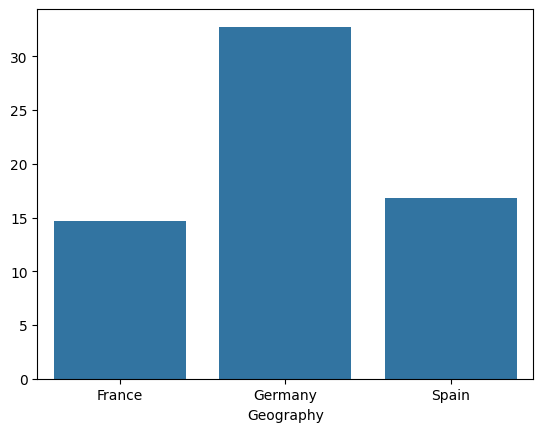

In [32]:
sns.barplot(x=rate.index,y=rate.values)
plt.show()

Q Whats the churn pattern for the customers with low credit scores and high balance?

In [33]:
risk=df[(df['Balance']>100000) &(df['CreditScore']<600)]
risk.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,agegrp
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1,41-50
7,8,15656148,Obinna,376,Germany,Female,37.0,4,115046.74,4,1,0,119346.88,1,31-40
8,9,15792365,He,501,France,Male,44.0,4,142051.07,2,0,1,74940.50,0,41-50
10,11,15767821,Bearce,528,France,Male,31.0,6,102016.72,2,0,0,80181.12,0,31-40
28,29,15728693,McWilliams,574,Germany,Male,43.0,3,141349.43,1,1,1,100187.43,0,41-50


In [34]:
rate=risk.groupby('Exited')['CreditScore'].mean()*100
rate

,CreditScore
Exited,
0,53735.721018
1,53220.204604


In [35]:
rate=risk['Exited'].mean()*100
rate

np.float64(26.92837465564738)

Q Is the churn rate higher among inactive members with only one product?

In [36]:
prod=df[df['NumOfProducts']==1]
rate=prod.groupby('IsActiveMember')['Exited'].mean()*100
rate

,Exited
IsActiveMember,
0,36.652122
1,18.923137


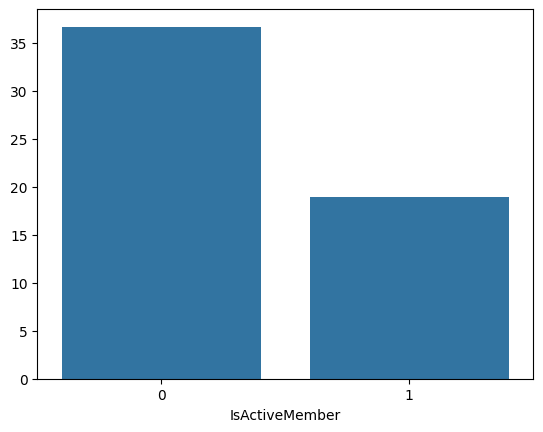

In [37]:
sns.barplot(x=rate.index,y=rate.values)
plt.show()

# Data Quality and Outliers

Q Are there any outliers in creditscore,age,balance or estimated salary?

In [54]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.919900,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.456444,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [62]:
def detoutliers(column):
  q1=df[column].quantile(0.25)
  q3=df[column].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr
  outliers=df[(df[column]<lower) | (df[column]>upper)]
  return outliers

In [64]:
out=detoutliers('CreditScore')
out.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,agegrp
7,8,15656148,Obinna,376,Germany,Female,37.0,4,115046.74,4,1,0,119346.88,1,31-40
942,943,15804586,Lin,376,France,Female,46.0,6,0.00,1,1,0,157333.69,1,41-50
1193,1194,15779947,Thomas,363,Spain,Female,28.0,6,146098.43,3,1,0,100615.14,1,18-30
1405,1406,15612494,Panicucci,359,France,Female,44.0,6,128747.69,1,1,0,146955.71,1,41-50
1631,1632,15685372,Azubuike,350,Spain,Male,54.0,1,152677.48,1,1,1,191973.49,1,51-60


In [65]:
out=detoutliers('Age')
out.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,agegrp
58,59,15623944,T'ien,511,Spain,Female,66.0,4,0.00,1,1,0,1643.11,1,61+
85,86,15805254,Ndukaku,652,Spain,Female,75.0,10,0.00,2,1,1,114675.75,0,61+
104,105,15804919,Dunbabin,670,Spain,Female,65.0,1,0.00,1,1,1,177655.68,1,61+
158,159,15589975,Maclean,646,France,Female,73.0,6,97259.25,1,0,1,104719.66,0,61+
181,182,15789669,Hsia,510,France,Male,65.0,2,0.00,2,1,1,48071.61,0,61+


In [66]:
out=detoutliers('Balance')
out.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,agegrp


In [67]:
out=detoutliers('EstimatedSalary')
out.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,agegrp


Q Does people with very high estimated salery also churn?

In [78]:
high=df.EstimatedSalary.quantile(0.95)
ppl=df[df['EstimatedSalary']>high]
rate=ppl['Exited'].mean()*100
rate

np.float64(20.8)

In [79]:
overall_churn=df['Exited'].mean()*100
overall_churn

np.float64(20.369999999999997)

* Yes people with high estimatedc salary also churn

In [38]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,agegrp
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1,41-50
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0,41-50
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1,41-50
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0,31-40
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0,41-50
